In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch 
import os 
from torch import nn
import torch.nn.functional as F 
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.tensorboard import SummaryWriter

%load_ext tensorboard

In [2]:
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
)

(x_train, y_train) = train_data.data[:].detach().numpy(), train_data.targets[:].detach().numpy()
(x_test, y_test) = test_data.data[:].detach().numpy(), test_data.targets[:].detach().numpy()
print(f"Training data: {x_train.shape}, {y_train.shape}")
print(f"Testing data: {x_test.shape}, {y_test.shape}")

Training data: (60000, 28, 28), (60000,)
Testing data: (10000, 28, 28), (10000,)


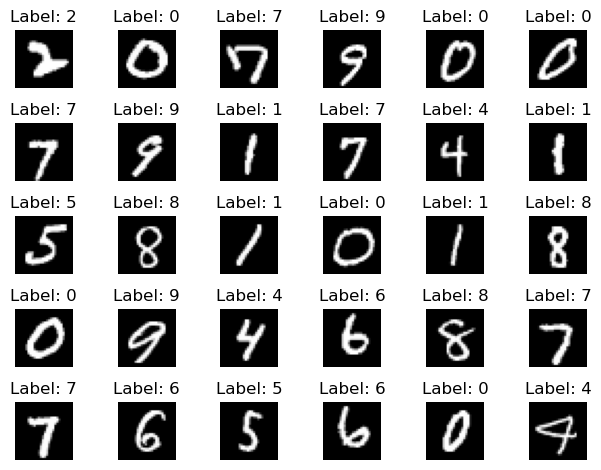

In [3]:
for i in range(30):
    idx = np.random.randint(0, x_train.shape[0])
    plt.subplot(5, 6, i+1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(f"Label: {y_train[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
batch_size = 256
num_classes = 10
epochs = 20

img_rows, img_cols = 28, 28

x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols).astype("float32") / 255.0
x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols).astype("float32") / 255.0
input_shape = (1, img_rows, img_cols)

In [5]:
print(x_train.shape, y_train.shape)

(60000, 1, 28, 28) (60000,)


In [6]:
class SiLU(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)
    
class DeepModel(nn.Module):
    def __init__(self, num_classes=10):
        super(DeepModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        x = F.log_softmax(x, dim=1)
        return x

model = DeepModel(num_classes=num_classes)
print(model)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

DeepModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=12544, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


In [7]:
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {params}")

Total trainable parameters: 6446986


In [8]:
class Generator(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_dataset = Generator(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = Generator(x_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [9]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
model.to(device)
criterion.to(device)

CrossEntropyLoss()

In [10]:
def train(model, epoch, writer):
    model.train()
    model.to(device)
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 50 == 49:
            writer.add_scalar("Loss/batch", running_loss / 50, epoch * len(train_loader) + batch_idx)
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    writer.add_scalar("Loss/train", avg_loss, epoch)

In [11]:
def test(model, epoch, writer):
    model.eval()
    model.to(device)
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_dataloader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_dataloader.dataset)
    accuracy = correct / len(test_dataloader.dataset)
    print(f"Test set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_dataloader.dataset)} ({accuracy:.2%})")
    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", accuracy, epoch)

In [12]:
def train_and_test(model, epochs, summary_path = "runs/mnist_experiment"):
    summary_writer = SummaryWriter(summary_path)
    for epoch in range(epochs):
        train(model, epoch, summary_writer)
        test(model, epoch, summary_writer)
    summary_writer.close()


In [13]:
train_and_test(model, epochs)

Epoch 1/20, Loss: 0.2134
Test set: Average loss: 0.0002, Accuracy: 9843/10000 (98.43%)
Epoch 2/20, Loss: 0.0533
Test set: Average loss: 0.0001, Accuracy: 9882/10000 (98.82%)
Epoch 3/20, Loss: 0.0344
Test set: Average loss: 0.0002, Accuracy: 9864/10000 (98.64%)
Epoch 4/20, Loss: 0.0248
Test set: Average loss: 0.0001, Accuracy: 9892/10000 (98.92%)
Epoch 5/20, Loss: 0.0202
Test set: Average loss: 0.0001, Accuracy: 9903/10000 (99.03%)
Epoch 6/20, Loss: 0.0158
Test set: Average loss: 0.0001, Accuracy: 9890/10000 (98.90%)
Epoch 7/20, Loss: 0.0132
Test set: Average loss: 0.0001, Accuracy: 9899/10000 (98.99%)
Epoch 8/20, Loss: 0.0117
Test set: Average loss: 0.0002, Accuracy: 9882/10000 (98.82%)
Epoch 9/20, Loss: 0.0103
Test set: Average loss: 0.0001, Accuracy: 9902/10000 (99.02%)
Epoch 10/20, Loss: 0.0079
Test set: Average loss: 0.0001, Accuracy: 9909/10000 (99.09%)
Epoch 11/20, Loss: 0.0078
Test set: Average loss: 0.0001, Accuracy: 9905/10000 (99.05%)
Epoch 12/20, Loss: 0.0078
Test set: Avera

In [14]:
class SimpleModel(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.5, activation=F.relu):
        super(SimpleModel, self).__init__()
        self.dense1 = nn.Linear(28*28, 128)
        self.dense2 = nn.Linear(128, num_classes)
        self.activation = activation
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.activation(self.dense1(x))
        x = self.dropout(x)
        x = self.dense2(x)
        return F.log_softmax(x, dim=1)



In [15]:
simple_model_relu = SimpleModel(num_classes=num_classes, dropout_rate=0.25, activation=F.relu)
simple_model_silu = SimpleModel(num_classes=num_classes, dropout_rate=0.25, activation=SiLU())
simple_model_gelu = SimpleModel(num_classes=num_classes, dropout_rate=0.25, activation=F.gelu)

param_relu = sum(p.numel() for p in simple_model_relu.parameters() if p.requires_grad)
param_silu = sum(p.numel() for p in simple_model_silu.parameters() if p.requires_grad)
param_gelu = sum(p.numel() for p in simple_model_gelu.parameters() if p.requires_grad)

print(f"SimpleModel with ReLU: {param_relu} parameters")
print(f"SimpleModel with SiLU: {param_silu} parameters")
print(f"SimpleModel with GELU: {param_gelu} parameters")

SimpleModel with ReLU: 101770 parameters
SimpleModel with SiLU: 101770 parameters
SimpleModel with GELU: 101770 parameters


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(simple_model_relu.parameters(), lr=0.001)
simple_model_relu.to(device)
criterion.to(device)
train_and_test(simple_model_relu, epochs, summary_path="runs/simple_relu")

Epoch 1/20, Loss: 0.5701
Test set: Average loss: 0.0010, Accuracy: 9249/10000 (92.49%)
Epoch 2/20, Loss: 0.2652
Test set: Average loss: 0.0008, Accuracy: 9423/10000 (94.23%)
Epoch 3/20, Loss: 0.2038
Test set: Average loss: 0.0006, Accuracy: 9535/10000 (95.35%)
Epoch 4/20, Loss: 0.1697
Test set: Average loss: 0.0005, Accuracy: 9612/10000 (96.12%)
Epoch 5/20, Loss: 0.1450
Test set: Average loss: 0.0005, Accuracy: 9645/10000 (96.45%)
Epoch 6/20, Loss: 0.1279
Test set: Average loss: 0.0004, Accuracy: 9672/10000 (96.72%)
Epoch 7/20, Loss: 0.1145
Test set: Average loss: 0.0004, Accuracy: 9697/10000 (96.97%)
Epoch 8/20, Loss: 0.1020
Test set: Average loss: 0.0004, Accuracy: 9730/10000 (97.30%)
Epoch 9/20, Loss: 0.0964
Test set: Average loss: 0.0003, Accuracy: 9738/10000 (97.38%)
Epoch 10/20, Loss: 0.0881
Test set: Average loss: 0.0003, Accuracy: 9746/10000 (97.46%)
Epoch 11/20, Loss: 0.0817
Test set: Average loss: 0.0003, Accuracy: 9745/10000 (97.45%)
Epoch 12/20, Loss: 0.0752
Test set: Avera

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(simple_model_silu.parameters(), lr=0.001)
simple_model_silu.to(device)
criterion.to(device)
train_and_test(simple_model_silu, epochs, summary_path="runs/simple_silu")

Epoch 1/20, Loss: 0.5762
Test set: Average loss: 0.0011, Accuracy: 9195/10000 (91.95%)
Epoch 2/20, Loss: 0.2758
Test set: Average loss: 0.0008, Accuracy: 9402/10000 (94.02%)
Epoch 3/20, Loss: 0.2093
Test set: Average loss: 0.0006, Accuracy: 9538/10000 (95.38%)
Epoch 4/20, Loss: 0.1683
Test set: Average loss: 0.0005, Accuracy: 9615/10000 (96.15%)
Epoch 5/20, Loss: 0.1441
Test set: Average loss: 0.0005, Accuracy: 9650/10000 (96.50%)
Epoch 6/20, Loss: 0.1244
Test set: Average loss: 0.0004, Accuracy: 9683/10000 (96.83%)
Epoch 7/20, Loss: 0.1099
Test set: Average loss: 0.0004, Accuracy: 9714/10000 (97.14%)
Epoch 8/20, Loss: 0.0997
Test set: Average loss: 0.0003, Accuracy: 9736/10000 (97.36%)
Epoch 9/20, Loss: 0.0888
Test set: Average loss: 0.0003, Accuracy: 9751/10000 (97.51%)
Epoch 10/20, Loss: 0.0820
Test set: Average loss: 0.0003, Accuracy: 9754/10000 (97.54%)
Epoch 11/20, Loss: 0.0750
Test set: Average loss: 0.0003, Accuracy: 9758/10000 (97.58%)
Epoch 12/20, Loss: 0.0695
Test set: Avera

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(simple_model_gelu.parameters(), lr=0.001)
simple_model_gelu.to(device)
criterion.to(device)
train_and_test(simple_model_gelu, epochs, summary_path="runs/simple_gelu")

Epoch 1/20, Loss: 0.5573
Test set: Average loss: 0.0011, Accuracy: 9219/10000 (92.19%)
Epoch 2/20, Loss: 0.2655
Test set: Average loss: 0.0008, Accuracy: 9438/10000 (94.38%)
Epoch 3/20, Loss: 0.2002
Test set: Average loss: 0.0006, Accuracy: 9558/10000 (95.58%)
Epoch 4/20, Loss: 0.1624
Test set: Average loss: 0.0005, Accuracy: 9649/10000 (96.49%)
Epoch 5/20, Loss: 0.1373
Test set: Average loss: 0.0004, Accuracy: 9681/10000 (96.81%)
Epoch 6/20, Loss: 0.1193
Test set: Average loss: 0.0004, Accuracy: 9713/10000 (97.13%)
Epoch 7/20, Loss: 0.1056
Test set: Average loss: 0.0004, Accuracy: 9729/10000 (97.29%)
Epoch 8/20, Loss: 0.0954
Test set: Average loss: 0.0003, Accuracy: 9741/10000 (97.41%)
Epoch 9/20, Loss: 0.0859
Test set: Average loss: 0.0003, Accuracy: 9752/10000 (97.52%)
Epoch 10/20, Loss: 0.0778
Test set: Average loss: 0.0003, Accuracy: 9762/10000 (97.62%)
Epoch 11/20, Loss: 0.0730
Test set: Average loss: 0.0003, Accuracy: 9768/10000 (97.68%)
Epoch 12/20, Loss: 0.0661
Test set: Avera

In [20]:
learning_rates = [1E-0, 1E-1, 1E-2, 1E-3, 1E-4, 1E-5]

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model = DeepModel(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_and_test(model, epochs, summary_path=f"runs/deep_model_lr_{lr}")


Training with learning rate: 1.0
Epoch 1/20, Loss: 122327.8257
Test set: Average loss: 0.0092, Accuracy: 1135/10000 (11.35%)
Epoch 2/20, Loss: 2.3182
Test set: Average loss: 0.0094, Accuracy: 958/10000 (9.58%)
Epoch 3/20, Loss: 2.3217
Test set: Average loss: 0.0093, Accuracy: 974/10000 (9.74%)
Epoch 4/20, Loss: 2.3258
Test set: Average loss: 0.0092, Accuracy: 974/10000 (9.74%)
Epoch 5/20, Loss: 2.3277
Test set: Average loss: 0.0093, Accuracy: 958/10000 (9.58%)
Epoch 6/20, Loss: 2.3290
Test set: Average loss: 0.0092, Accuracy: 1032/10000 (10.32%)
Epoch 7/20, Loss: 2.3255
Test set: Average loss: 0.0093, Accuracy: 1010/10000 (10.10%)
Epoch 8/20, Loss: 2.3291
Test set: Average loss: 0.0093, Accuracy: 980/10000 (9.80%)
Epoch 9/20, Loss: 2.3301
Test set: Average loss: 0.0094, Accuracy: 980/10000 (9.80%)
Epoch 10/20, Loss: 2.3326
Test set: Average loss: 0.0094, Accuracy: 1135/10000 (11.35%)
Epoch 11/20, Loss: 2.3317
Test set: Average loss: 0.0093, Accuracy: 1135/10000 (11.35%)
Epoch 12/20, L

In [21]:
def train(model, optimizer, scheduler, epoch, writer):
    model.train()
    model.to(device)
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 50 == 49:
            writer.add_scalar("Loss/batch", running_loss / 50, epoch * len(train_loader) + batch_idx)
            writer.add_scalar("Learning Rate", optimizer.param_groups[0]['lr'], epoch * len(train_loader) + batch_idx)
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
    writer.add_scalar("Loss/train", avg_loss, epoch)
    if scheduler is not None:
        scheduler.step()

In [22]:
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

def train_and_test(model, epochs, summary_path = "runs/mnist_experiment"):
    summary_writer = SummaryWriter(summary_path)
    for epoch in range(epochs):
        train(model, optimizer, scheduler, epoch, summary_writer)
        test(model, epoch, summary_writer)
    summary_writer.close()

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
model.to(device)
criterion.to(device)
train_and_test(model, epochs)

Epoch 1/20, Loss: 0.1763, Learning Rate: 0.001000
Test set: Average loss: 0.0003, Accuracy: 9777/10000 (97.77%)
Epoch 2/20, Loss: 0.0603, Learning Rate: 0.000900
Test set: Average loss: 0.0002, Accuracy: 9853/10000 (98.53%)
Epoch 3/20, Loss: 0.0418, Learning Rate: 0.000810
Test set: Average loss: 0.0001, Accuracy: 9891/10000 (98.91%)
Epoch 4/20, Loss: 0.0289, Learning Rate: 0.000729
Test set: Average loss: 0.0001, Accuracy: 9886/10000 (98.86%)
Epoch 5/20, Loss: 0.0224, Learning Rate: 0.000656
Test set: Average loss: 0.0001, Accuracy: 9913/10000 (99.13%)
Epoch 6/20, Loss: 0.0180, Learning Rate: 0.000590
Test set: Average loss: 0.0001, Accuracy: 9895/10000 (98.95%)
Epoch 7/20, Loss: 0.0142, Learning Rate: 0.000531
Test set: Average loss: 0.0001, Accuracy: 9906/10000 (99.06%)
Epoch 8/20, Loss: 0.0117, Learning Rate: 0.000478
Test set: Average loss: 0.0001, Accuracy: 9919/10000 (99.19%)
Epoch 9/20, Loss: 0.0092, Learning Rate: 0.000430
Test set: Average loss: 0.0001, Accuracy: 9908/10000 (